# Apoptosis Quantification Analysis

This notebook performs automated quantification of apoptosis in 3D acini using cleaved caspase-3 (C3) staining. It segments acini, identifies C3-positive cells, counts total nuclei, and analyzes spatial distribution of apoptotic cells within the acinar structure.

## Analysis Overview
1. Load and rescale 3D fluorescent images
2. Segment acini boundaries
3. Identify C3-positive (apoptotic) cells using watershed segmentation
4. Count total nuclei (DAPI-positive)
5. Calculate spatial metrics and quantify apoptosis per acinus

In [1]:
import numpy as np
import pandas as pd
import os
import pathlib
from joblib import Parallel, delayed
import contextlib
import joblib
from tqdm import tqdm
import warnings

from skimage import util
from skimage.filters import threshold_otsu, gaussian
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max

from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage.segmentation import expand_labels

from tifffile import imread
import tifffile

import napari

warnings.filterwarnings("ignore")

c:\Users\isobe\anaconda3\envs\imaging_record\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.
    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [3]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Convert an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [4]:
def pixel_size(tif_path):
    """
    Extract pixel size information from TIFF metadata.

    Parameters
    ----------
    tif_path : str
        Path to the TIFF file.

    Returns
    -------
    list
        List containing [x_pixel_size_um, y_pixel_size_um, z_pixel_size_um].
    """
    with tifffile.TiffFile(tif_path) as tif:
        tif_tags = {}
        for tag in tif.pages[0].tags.values():
            name, value = tag.name, tag.value
            tif_tags[name] = value

        x_pixel_size_um = 1/((tif_tags["XResolution"])[0]/(tif_tags["XResolution"][1]))
        y_pixel_size_um = 1/((tif_tags["YResolution"])[0]/(tif_tags["YResolution"][1]))
        try:
            z_pixel_size_um = float(str(tif_tags["IJMetadata"]).split("nscales=")[1].split(",")[2].split("\\nunit")[0])
        except:
            z_pixel_size_um = (float(str(tif_tags["ImageDescription"]).split("spacing=")[1].split("loop")[0]))
       
    original_spacing = [x_pixel_size_um, y_pixel_size_um, z_pixel_size_um]
    return original_spacing

In [5]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [6]:
def add_image_details(df, filename, flag):
    """
    Add experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.
    flag : str
        A flag indicating any segmentation issues detected during processing.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'flag': Segmentation flag indicating potential issues.
        - 'well': The well number (1 or 2) inferred from the filename.
        - 'day': The experimental time point (0, 1, 3, or 7 days).
        - 'condition': The mechanical stiffness condition ('soft', 'stiff', or 'blank').
        - 'treatment': The treatment applied ('blebbistatin', 'ROCKi', 'batimastat', 'ABT737', or 'none').
        - 'image_type': A combined descriptor of the condition and day (e.g., 'soft, d3').
    """
    df["filename"] = filename
    df["flag"] = flag
    
    # Well number
    if "well1" in filename:
        df["well"] = 1
    else:
        df["well"] = 2
    
    # Day
    if "d0" in filename:
        df["day"] = 0
    elif "d1" in filename:
        df["day"] = 1
    elif "d3" in filename:
        df["day"] = 3
    else:
        df["day"] = 7
    
    # Stiffness
    if 'soft' in filename:
        df["condition"] = 'soft'
    elif 'stiff' in filename:
        df["condition"] = 'stiff'
    else:
        df["condition"] = 'blank'
    
    # Treatment
    if "bleb" in filename.lower():
        df["treatment"] = "blebbistatin"
    elif "rock" in filename.lower():
        df["treatment"] = "ROCKi"
    elif ("batimastat" in filename.lower()) or "mmpi" in filename.lower():
        df["treatment"] = "batimastat"
    elif "abt" in filename.lower():
        df["treatment"] = "ABT737"
    else:
        df["treatment"] = "none"
    
    df['image_type'] = df["condition"].astype(str) + ", d" + df["day"].astype(str)
    return df

In [7]:
def clean_and_watershed(image, acinus_labelled_image, new_pixel_size, separation_in_um=4, radius_threshold_um=2):
    """
    Clean binary mask and perform watershed segmentation to separate individual nuclei.

    Parameters
    ----------
    image : numpy.ndarray
        Binary or intensity image to segment.
    acinus_labelled_image : numpy.ndarray
        Labeled image defining acinus boundaries.
    new_pixel_size : float
        Pixel size in micrometers after rescaling.
    separation_in_um : float, optional
        Minimum distance in micrometers between detected nuclei centers (default: 4).
    radius_threshold_um : float, optional
        Minimum nuclear radius in micrometers for filtering (default: 2).

    Returns
    -------
    watershed_output : numpy.ndarray
        Labeled image with segmented and filtered nuclei.
    """
    cleaned_mask = image * acinus_labelled_image
    cleaned_mask = gaussian(cleaned_mask, 0.8)
    thresh = threshold_otsu(cleaned_mask)
    cleaned_mask = cleaned_mask > thresh
    cleaned_mask = remove_small_objects(cleaned_mask, min_size=1000)
    cleaned_mask = remove_small_holes(cleaned_mask, area_threshold=500)
    cleaned_mask = opening(cleaned_mask, ball(5))
    
    # Watershed nuclei
    distances = ndi.distance_transform_edt(erosion(cleaned_mask, ball(3)))
    nuclear_size_in_pixels = separation_in_um / new_pixel_size
    coordinates = peak_local_max(distances, min_distance=int(nuclear_size_in_pixels))
    marker_locations = coordinates.data
    markers = np.zeros(cleaned_mask.shape, dtype=np.uint32)
    marker_indices = tuple(np.round(marker_locations).astype(int).T)
    markers[marker_indices] = np.arange(len(marker_locations)) + 1
    markers_big = dilation(markers, ball(2))
    segmented = watershed(-distances, markers_big, mask=cleaned_mask)
    segmented = clear_border(segmented)
    
    # Filter out small nuclei
    table = regionprops_table(segmented, properties=('label', 'area'))
    volume_threshold = (4/3) * np.pi * (radius_threshold_um / new_pixel_size)**3
    condition = (table['area'] >= volume_threshold)
    input_labels = table['label']
    output_labels = input_labels * condition
    watershed_output = util.map_array(segmented, input_labels, output_labels)

    return watershed_output

In [8]:
def segment_and_quantify(i, image_paths, c3_segmentation_paths, dapi_segmentation_paths, DAPI_channel=0, C3_channel=3, membrane_channel = None, proximity_protein_channel = None, to_plot=False, search_radius_um=5): 
    """
    Segment acini and quantify C3-positive apoptotic cells.

    This function processes 3D fluorescent images to segment acini, identify C3-positive 
    (apoptotic) cells, count total nuclei, and calculate spatial metrics.

    Parameters
    ----------
    i : int
        Index of the image to process from the paths lists.
    image_paths : list
        List of paths to the raw TIFF image files.
    c3_segmentation_paths : list
        List of paths to C3 binary segmentation masks.
    dapi_segmentation_paths : list
        List of paths to DAPI binary segmentation masks.
    DAPI_channel : int, optional
        Channel index for DAPI (default: 0).
    C3_channel : int, optional
        Channel index for C3 (default: 3).
    to_plot : bool, optional
        If True, return additional arrays for visualization (default: False).

    Returns
    -------
    C3_props : pandas.DataFrame
        DataFrame containing C3-positive cell properties including:
        - label: Cell identifier
        - centroid coordinates (centroid-0, centroid-1, centroid-2)
        - corresponding_distance_matrix: Normalized distance from acinus center
        - C3_volume_um: Volume of C3-positive region in cubic micrometers
        - acinus_vol_in_um: Total acinus volume
        - acinus_roundness: Acinus shape metric
        - number_of_nuclei: Total DAPI-positive nuclei count
        - Experimental metadata (filename, well, day, condition, treatment, etc.)
    
    If to_plot is True, also returns:
        C3_labels, C3_rescaled, distance_scaled, dapi_labels, filtered_labelled_image, 
        acinus_rescaled, rgb_image
    """
    image = convert(imread(image_paths[i]), 0, 255, np.uint8)
    flag = "None"
    filename = str((os.path.basename(image_paths[i]))).lower()
    print(filename)
    
    try:
        # Scale the images
        acinus_image = image[:, DAPI_channel, :, :] + image[:, C3_channel, :, :]
        if membrane_channel is not None:
            acinus_image = acinus_image + image[:, membrane_channel, :, :]
        
        c3_mask = imread(c3_segmentation_paths[i])
        dapi_mask = imread(dapi_segmentation_paths[i])

        original_spacing = pixel_size(image_paths[i])
        scale_change = original_spacing[2] / original_spacing[0]
        new_pixel_size = 4 * original_spacing[0]
        acinus_rescaled = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=acinus_image, anti_aliasing=False)
        C3_rescaled = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=image[:, C3_channel, :, :], anti_aliasing=False)
        rescaled_c3_mask = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=c3_mask, anti_aliasing=False)
        # rescaled_dapi_mask = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=dapi_mask, anti_aliasing=False)
        recaled_live_cells = rescale(scale = (0.25*scale_change, 0.25, 0.25), image = (dapi_mask - dilation(c3_mask,ball(2))), anti_aliasing= False) #dapi no EDU
        rescaled_live_cells = np.where(recaled_live_cells > 1, 0, recaled_live_cells)
        print(rescaled_live_cells.max(), rescaled_live_cells.min()) #DAPI NO EDU - mask values > 1

        rescaled_c3_image = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=image[:, C3_channel, :, :], anti_aliasing=False)
        rescaled_dapi_image = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=image[:, DAPI_channel, :, :], anti_aliasing=False)
        if proximity_protein_channel is not None:
            rescaled_proximity_protein_image = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=image[:, proximity_protein_channel, :, :], anti_aliasing=False)

        # Create RGB image with optional membrane channel
        if membrane_channel is not None:
            rescaled_membrane_image = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=image[:, membrane_channel, :, :], anti_aliasing=False)
            rgb_image = np.stack([rescaled_c3_image, rescaled_membrane_image, rescaled_dapi_image], axis=-1)
        else:
            rgb_image = np.stack([rescaled_c3_image, np.zeros_like(rescaled_c3_image), rescaled_dapi_image], axis=-1)

        # Clip and pre-process the acinus image to identify boundaries
        clipped = (acinus_rescaled).clip(min=np.quantile(acinus_rescaled, 0.05), max=np.quantile(acinus_rescaled, 0.85))
        acinus_smoothed = gaussian(clipped, sigma=12)
        thresh = threshold_otsu(acinus_smoothed)
        binary = acinus_smoothed > thresh
        binary = remove_small_holes(binary, area_threshold=100000)
        binary = remove_small_objects(binary, min_size=10000)
        # binary = erosion(binary, ball(5))
        labelled_image = label(binary)
        table = regionprops_table(labelled_image, properties=('label', 'area'))
        condition = (table['area'] >= table['area'].max())
        # Filter the labels so we only keep the largest one
        input_labels = table['label']
        output_labels = input_labels * condition
        acinus_label = util.map_array(labelled_image, input_labels, output_labels)
        acinus_vol_in_um = [(region.area) * (new_pixel_size**3) for region in regionprops(acinus_label)][0]
        acinus_roundness = [(region.inertia_tensor_eigvals[2] / region.inertia_tensor_eigvals[0]) for region in regionprops(acinus_label)][0]

        # Identify C3* +ve objects and all nuclei
        C3_labels = clean_and_watershed(rescaled_c3_mask, acinus_label, new_pixel_size, separation_in_um=7, radius_threshold_um=3)
        live_cell_labels = clean_and_watershed(rescaled_live_cells, acinus_label, new_pixel_size, separation_in_um=6, radius_threshold_um=3)
#############################################

        distance = (distance_transform_edt(acinus_label>0))
        distance_scaled = np.interp(distance, (distance.min(), distance.max()), (0, +1))
        
        dying_cell_info = pd.DataFrame(regionprops_table(C3_labels, properties = ("label", "area", "centroid")))
        non_dying_cell_info = pd.DataFrame(regionprops_table(live_cell_labels, properties = ("label", "area", "centroid")))

        # Convert area (in pixels) to volume in um^3
        dying_cell_info["nuclear_or_c3_volume_um3"] = dying_cell_info["area"] * (new_pixel_size**3)
        dying_cell_info.drop('area', axis=1, inplace=True)
        
        non_dying_cell_info["nuclear_or_c3_volume_um3"] = non_dying_cell_info["area"] * (new_pixel_size**3)
        non_dying_cell_info.drop('area', axis=1, inplace=True)

##########    acinus_vol_um = [(region.area)*(new_pixel_size**3) for region in regionprops(filtered_labelled_acinus)][0]




        dying_cell_info["dying"] = "Y"
        number_dividing = dying_cell_info.shape[0]
        non_dying_cell_info["dying"] = "N"
        number_not_dividing = non_dying_cell_info.shape[0]

        all_cell_info = pd.concat((dying_cell_info, non_dying_cell_info))
        all_cell_info["acinus_volume_um3"] = acinus_vol_in_um
        all_cell_info["acinus_roundness"] = acinus_roundness

        if all_cell_info.shape[0] == 0:
            all_cell_info =pd.DataFrame(columns= ["label", "centroid-0",	"centroid-1",	"centroid-2",	"corresponding_distance_matrix"], data = [[np.NaN,np.NaN,np.NaN,np.NaN,np.NaN, np.NaN]] )
        else:
            all_cell_info["corresponding_distance_matrix"] = all_cell_info.apply(lambda x: distance_scaled[round(x['centroid-0']), round(x['centroid-1']), round(x['centroid-2'])], axis=1)
            all_cell_info["number_dying"] = number_dividing        
            all_cell_info["number_not_dying"] = number_not_dividing

        all_cell_info = add_image_details(all_cell_info,  filename, flag)

#########################################
        # Combine live_cell_labels and C3_labels, ensuring unique labels
        combined_labels = live_cell_labels.copy()
        if C3_labels.max() > 0:
            # Offset C3 labels to avoid overlap with live cell labels
            max_live_label = live_cell_labels.max()
            c3_labels_offset = np.where(C3_labels > 0, C3_labels + max_live_label, 0)
            combined_labels = np.where(combined_labels == 0, c3_labels_offset, combined_labels)

        # Expand all labels together to estimate cell territories
        estimated_cell_labels = acinus_label * expand_labels(combined_labels, distance=20)

        # Analyze proximity protein intensity if provided
        if proximity_protein_channel is not None:
            search_radius_pixels = int(search_radius_um / new_pixel_size)
            
            proximity_results = []
            for region in regionprops(estimated_cell_labels):
                cell_label = region.label
                
                cell_mask = (estimated_cell_labels == cell_label)
                cell_mask_labeled = np.where(cell_mask, 1, 0).astype(np.uint8)
                expanded_cell_mask_labeled = expand_labels(cell_mask_labeled, distance=search_radius_pixels)
                expanded_cell_mask = (expanded_cell_mask_labeled > 0)
                intensity_in_cell = rescaled_proximity_protein_image[cell_mask].sum()
                intensity_in_neighborhood = rescaled_proximity_protein_image[expanded_cell_mask].sum()
                intensity_around_cell = intensity_in_neighborhood - intensity_in_cell
                
                # Get volume measurements and convert to um^3
                cell_volume_pixels = cell_mask.sum()
                neighborhood_volume_pixels = expanded_cell_mask.sum()
                cell_volume_um3 = cell_volume_pixels * (new_pixel_size**3)
                neighborhood_volume_um3 = neighborhood_volume_pixels * (new_pixel_size**3)
                
                proximity_results.append({
                    'label': cell_label,
                    'proximity_intensity_in_cell': intensity_in_cell,
                    'proximity_intensity_around_cell': intensity_around_cell,
                    'proximity_intensity_total_neighborhood': intensity_in_neighborhood,
                    'proximity_mean_intensity_in_cell': intensity_in_cell / cell_volume_pixels if cell_volume_pixels > 0 else 0,
                    'proximity_mean_intensity_neighborhood': intensity_in_neighborhood / neighborhood_volume_pixels if neighborhood_volume_pixels > 0 else 0,
                    'estimated_cell_territory_volume_um3': cell_volume_um3,
                    'proximity_neighborhood_volume_um3': neighborhood_volume_um3
                })
            
            # Merge proximity results with cell info
            proximity_df = pd.DataFrame(proximity_results)
            all_cell_info = all_cell_info.merge(proximity_df, on='label', how='left')
            all_cell_info = add_image_details(all_cell_info, filename, flag)
        
        # Round all numeric columns to 2 decimal places
        numeric_columns = all_cell_info.select_dtypes(include=[np.number]).columns
        all_cell_info[numeric_columns] = all_cell_info[numeric_columns].round(2)
        
        # Reorder columns: filename, label, dying, distance_matrix first; centroids last
        first_cols = ['filename', 'label', 'dying', 'corresponding_distance_matrix']
        centroid_cols = ['centroid-0', 'centroid-1', 'centroid-2']
        middle_cols = [col for col in all_cell_info.columns if col not in first_cols + centroid_cols]
        all_cell_info = all_cell_info[first_cols + middle_cols + centroid_cols]
        
#########################################################################

        if to_plot:
            if proximity_protein_channel is not None:
                return (all_cell_info, estimated_cell_labels, C3_labels, live_cell_labels, acinus_label, rgb_image, rescaled_proximity_protein_image)
            else:
                return (all_cell_info, estimated_cell_labels, C3_labels, live_cell_labels, acinus_label, rgb_image, None)
    
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        all_cell_info = pd.DataFrame(columns=["label", "centroid-0", "centroid-1", "centroid-2", "corresponding_distance_matrix", "volume_um"], 
                               data=[["Fail", "Fail", "Fail", "Fail", "Fail", "Fail"]])
        all_cell_info["filename"] = filename
        all_cell_info["flag"] = "FAILED"
    
    return all_cell_info

## Single Image Analysis

Test the analysis pipeline on a single image to verify segmentation quality and parameters.

In [113]:
# Define paths to image directories
root = r"E:\Fabianna_N2_Images\integrin_analysis"
image_root = root + "\\tif"
c3_root = root + "\\combined_binary_c3"
dapi_root = root + "\\combined_binary_dapi"

# Get all image paths
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
c3_paths = list(pathlib.Path(c3_root).glob("**/*.tif"))
dapi_paths = list(pathlib.Path(dapi_root).glob("**/*.tif"))

print(f"Found {len(image_paths)} images, {len(c3_paths)} C3 masks, {len(dapi_paths)} DAPI masks")

Found 20 images, 20 C3 masks, 20 DAPI masks


In [118]:
# Process a single image for testing
i = 19
all_cell_info, estimated_cell_labels, C3_labels, live_cell_labels, acinus_label, rgb_image, rescaled_proximity_protein_image = segment_and_quantify(
    i, image_paths, c3_paths, dapi_paths, C3_channel=2, membrane_channel=1, proximity_protein_channel=3, to_plot=True, search_radius_um=2
)

d7_stiff_12g10_c3010_cmle.tif
1.0 0.0
1.0 0.0


In [119]:
all_cell_info.head()

,filename,label,dying,corresponding_distance_matrix,nuclear_or_c3_volume_um3,acinus_volume_um3,acinus_roundness,number_dying,number_not_dying,flag,...,proximity_intensity_in_cell,proximity_intensity_around_cell,proximity_intensity_total_neighborhood,proximity_mean_intensity_in_cell,proximity_mean_intensity_neighborhood,estimated_cell_territory_volume_um3,proximity_neighborhood_volume_um3,centroid-0,centroid-1,centroid-2
0,d7_stiff_12g10_c3010_cmle.tif,1,Y,0.18,4208.74,257025.39,0.83,5,49,None,...,316.18,162.44,478.62,0.0,0.0,16568.48,23492.51,117.70,117.80,59.81
1,d7_stiff_12g10_c3010_cmle.tif,2,Y,0.46,907.85,257025.39,0.83,5,49,None,...,131.88,102.97,234.85,0.0,0.0,5567.20,9153.54,114.65,102.03,87.63
2,d7_stiff_12g10_c3010_cmle.tif,3,Y,0.21,2327.69,257025.39,0.83,5,49,None,...,115.41,143.28,258.69,0.0,0.0,4426.50,7228.15,104.26,172.27,58.39
3,d7_stiff_12g10_c3010_cmle.tif,4,Y,0.21,1520.36,257025.39,0.83,5,49,None,...,16.14,22.16,38.30,0.0,0.0,1816.24,3513.05,111.91,37.23,118.17
4,d7_stiff_12g10_c3010_cmle.tif,5,Y,0.09,145.56,257025.39,0.83,5,49,None,...,17.68,23.33,41.01,0.0,0.0,2129.07,4109.85,142.41,31.78,190.13


In [120]:
# Visualize segmentation results in Napari
viewer = napari.Viewer()
viewer.add_image(rgb_image, name='RGB Composite')
viewer.add_labels(acinus_label, name='Acinus Image')
viewer.add_labels(C3_labels, name='C3 Labels')
viewer.add_labels(live_cell_labels, name='Live Cell Labels')
viewer.add_labels(estimated_cell_labels, name='Estimated Cell Territories')

# Add proximity protein channel if available
if rescaled_proximity_protein_image is not None:
    viewer.add_image(rescaled_proximity_protein_image, name='Proximity Protein', colormap='yellow')

## Batch Processing

Process all images in parallel to generate the complete dataset.

In [9]:
root = r"E:\Fabianna_N2_Images\integrin_analysis"
image_root = root + "\\tif"
c3_root = root + "\\combined_binary_c3"
dapi_root = root + "\\combined_binary_dapi"
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
c3_paths = list(pathlib.Path(c3_root).glob("**/*.tif"))
dapi_paths = list(pathlib.Path(dapi_root).glob("**/*.tif"))

print(f"Found {len(image_paths)} images, {len(c3_paths)} C3 masks, {len(dapi_paths)} DAPI masks")

Found 20 images, 20 C3 masks, 20 DAPI masks


In [10]:
for search_radius in [1,2,3,4]:

    # Process all images in parallel
    with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
        all_cell_info = Parallel(n_jobs=4)(
            delayed(segment_and_quantify)(i, image_paths, c3_paths, dapi_paths, C3_channel=2, membrane_channel=1, proximity_protein_channel=3,to_plot=False, search_radius_um=search_radius) 
            for i in range(len(image_paths))
        )

    # Combine results into a single DataFrame
    results_df = pd.concat(all_cell_info, ignore_index=True)
    results_df.to_csv(f"fabianna_integrin_analysis_search_radius_{search_radius}um.csv")
    print(f"\nAnalysis complete! Processed {len(image_paths)} images.")
    print(f"Total C3-positive cells detected: {results_df[results_df['label'] != 'no_c3'].shape[0]}")


Image Analysis: 100%|██████████| 20/20 [12:10<00:00, 36.50s/it]



Analysis complete! Processed 20 images.
Total C3-positive cells detected: 921


Image Analysis: 100%|██████████| 20/20 [12:11<00:00, 36.58s/it]



Analysis complete! Processed 20 images.
Total C3-positive cells detected: 921


Image Analysis: 100%|██████████| 20/20 [12:03<00:00, 36.16s/it]



Analysis complete! Processed 20 images.
Total C3-positive cells detected: 921


Image Analysis: 100%|██████████| 20/20 [11:47<00:00, 35.40s/it]


Analysis complete! Processed 20 images.
Total C3-positive cells detected: 921


In [29]:
results = pd.read_csv("fabianna_integrin_analysis_search_radius_1um.csv")
test = results.drop_duplicates(subset=['filename'], inplace=False)
test

,Unnamed: 0,filename,label,dying,corresponding_distance_matrix,nuclear_or_c3_volume_um3,acinus_volume_um3,acinus_roundness,number_dying,number_not_dying,...,proximity_intensity_around_cell,proximity_intensity_total_neighborhood,proximity_mean_intensity_in_cell,proximity_mean_intensity_neighborhood,estimated_cell_territory_volume_um3,proximity_neighborhood_volume_um3,centroid-0,centroid-1,centroid-2,volume_um
0,0,d7_soft_12g10_c3001_cmle.tif,1,Y,0.47,4548.47,185807.04,0.74,2.0,36.0,...,40.35,111.96,0.00,0.00,5347.15,6396.66,120.1,129.97,111.04,NaN
38,38,d7_soft_12g10_c3002_cmle.tif,1,Y,0.65,719.52,187609.01,0.85,3.0,91.0,...,54.20,155.39,0.00,0.00,3262.86,4164.10,77.12,130.91,152.17,NaN
132,132,d7_soft_12g10_c3003_cmle.tif,1,Y,0.54,3612.22,165139.55,0.79,7.0,57.0,...,8.89,26.04,0.00,0.00,4408.41,5417.91,126.55,108.87,147.71,NaN
196,196,d7_soft_12g10_c3004_cmle.tif,1,Y,0.49,3309.86,173425.83,0.88,5.0,45.0,...,24.57,48.17,0.00,0.00,2946.70,3666.86,114.3,107.7,74.83,NaN
246,246,d7_soft_12g10_c3005_cmle.tif,Fail,NaN,Fail,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Fail,Fail,Fail,Fail
247,247,d7_soft_12g10_c3006_cmle.tif,1,Y,0.4,658.98,204883.31,0.79,3.0,82.0,...,47.05,293.03,0.00,0.00,3149.06,4028.31,91.76,141.42,118.54,NaN
332,332,d7_soft_12g10_c3007_cmle.tif,1,Y,0.63,866.02,207653.13,0.70,2.0,58.0,...,152.47,1026.97,0.01,0.01,5577.10,6846.59,73.64,153.94,146.95,NaN
392,392,d7_soft_12g10_c3008_cmle.tif,1,Y,0.64,2845.72,80588.38,0.90,1.0,29.0,...,260.81,1321.91,0.01,0.01,3845.37,5097.53,102.21,137.11,139.05,NaN
422,422,d7_soft_12g10_c3009_cmle.tif,1,Y,0.88,7872.86,186259.66,0.75,3.0,47.0,...,61.67,277.84,0.00,0.00,7128.30,8473.36,87.25,122.5,124.09,NaN
472,472,d7_soft_12g10_c3010_cmle.tif,Fail,NaN,Fail,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Fail,Fail,Fail,Fail


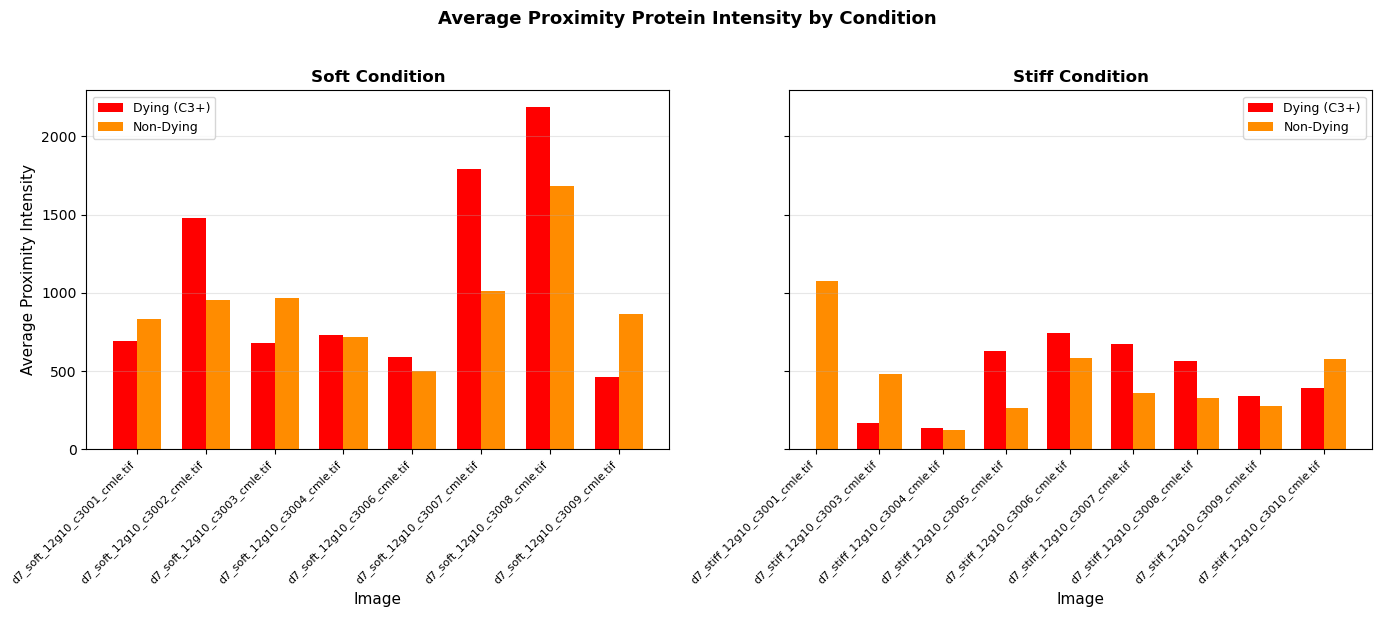

In [37]:
# Calculate average proximity intensity per filename for dying vs non-dying cells
avg_proximity = results_df.groupby(['filename', 'dying'])['proximity_intensity_total_neighborhood'].mean().reset_index()
avg_proximity.columns = ['filename', 'dying', 'avg_proximity_intensity']

# Pivot to get dying and non-dying as separate columns for easier plotting
avg_pivot = avg_proximity.pivot(index='filename', columns='dying', values='avg_proximity_intensity').reset_index()
avg_pivot.columns.name = None
avg_pivot = avg_pivot.rename(columns={'Y': 'dying_avg', 'N': 'non_dying_avg'})

# Add condition information
avg_pivot['condition'] = avg_pivot['filename'].apply(
    lambda x: 'soft' if 'soft' in x else ('stiff' if 'stiff' in x else 'other')
)

# Separate soft and stiff data
soft_data = avg_pivot[avg_pivot['condition'] == 'soft'].reset_index(drop=True)
stiff_data = avg_pivot[avg_pivot['condition'] == 'stiff'].reset_index(drop=True)

# Create side-by-side bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# SOFT condition bar plot
if len(soft_data) > 0:
    x_soft = np.arange(len(soft_data))
    width = 0.35
    
    bars1 = ax1.bar(x_soft - width/2, soft_data['dying_avg'], width, label='Dying (C3+)', color='red')
    bars2 = ax1.bar(x_soft + width/2, soft_data['non_dying_avg'], width, label='Non-Dying', color='darkorange')
    
    ax1.set_xlabel('Image', fontsize=11)
    ax1.set_ylabel('Average Proximity Intensity', fontsize=11)
    ax1.set_title('Soft Condition', fontsize=12, fontweight='bold')
    ax1.set_xticks(x_soft)
    ax1.set_xticklabels(soft_data['filename'], rotation=45, ha='right', fontsize=8)
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

# STIFF condition bar plot
if len(stiff_data) > 0:
    x_stiff = np.arange(len(stiff_data))
    width = 0.35
    
    bars3 = ax2.bar(x_stiff - width/2, stiff_data['dying_avg'], width, label='Dying (C3+)', color='red')
    bars4 = ax2.bar(x_stiff + width/2, stiff_data['non_dying_avg'], width, label='Non-Dying', color='darkorange')
    
    ax2.set_xlabel('Image', fontsize=11)
    ax2.set_title('Stiff Condition', fontsize=12, fontweight='bold')
    ax2.set_xticks(x_stiff)
    ax2.set_xticklabels(stiff_data['filename'], rotation=45, ha='right', fontsize=8)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Average Proximity Protein Intensity by Condition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



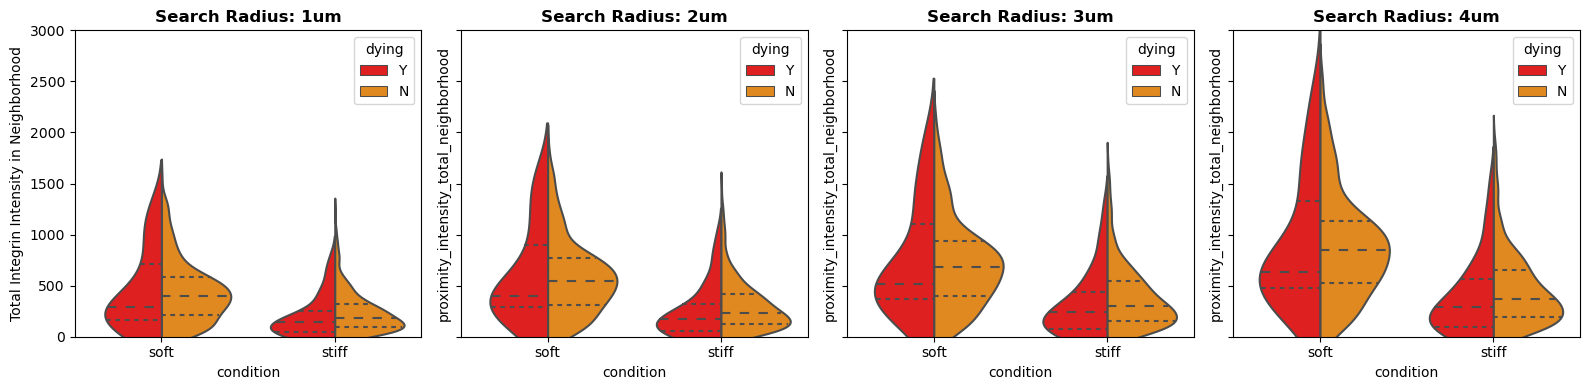

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols = 4, figsize=(16,4), sharey=True)

for i, csv in enumerate(["fabianna_integrin_analysis_search_radius_1um.csv", "fabianna_integrin_analysis_search_radius_2um.csv", "fabianna_integrin_analysis_search_radius_3um.csv", "fabianna_integrin_analysis_search_radius_4um.csv"]):
    results = pd.read_csv(csv)
    test = results.drop_duplicates(subset=['filename'], inplace=False)
    sns.violinplot(data=results, x='condition', y='proximity_intensity_total_neighborhood', hue='dying', split=True, inner='quartile', palette=["red", "darkorange"], ax=ax[i])
    # sns.violinplot(data=results_df, x='dying', y='proximity_intensity_total_neighborhood', hue='condition', split=True, inner='quartile', palette=["limegreen", "dodgerblue"], ax=ax[1])
    ax[0].set_ylabel("Total Integrin Intensity in Neighborhood")
    ax[i].set_title(f"Search Radius: {csv.split('_')[-1].split('.')[0]}", fontsize=12, fontweight='bold')
    ax[i].set_ylim(0,3000)
plt.tight_layout()
plt.savefig(f"fabianna_integrin_analysis_violin_plots.png", dpi=300)
plt.savefig(f"fabianna_integrin_analysis_violin_plots.pdf", dpi=300)

plt.show()


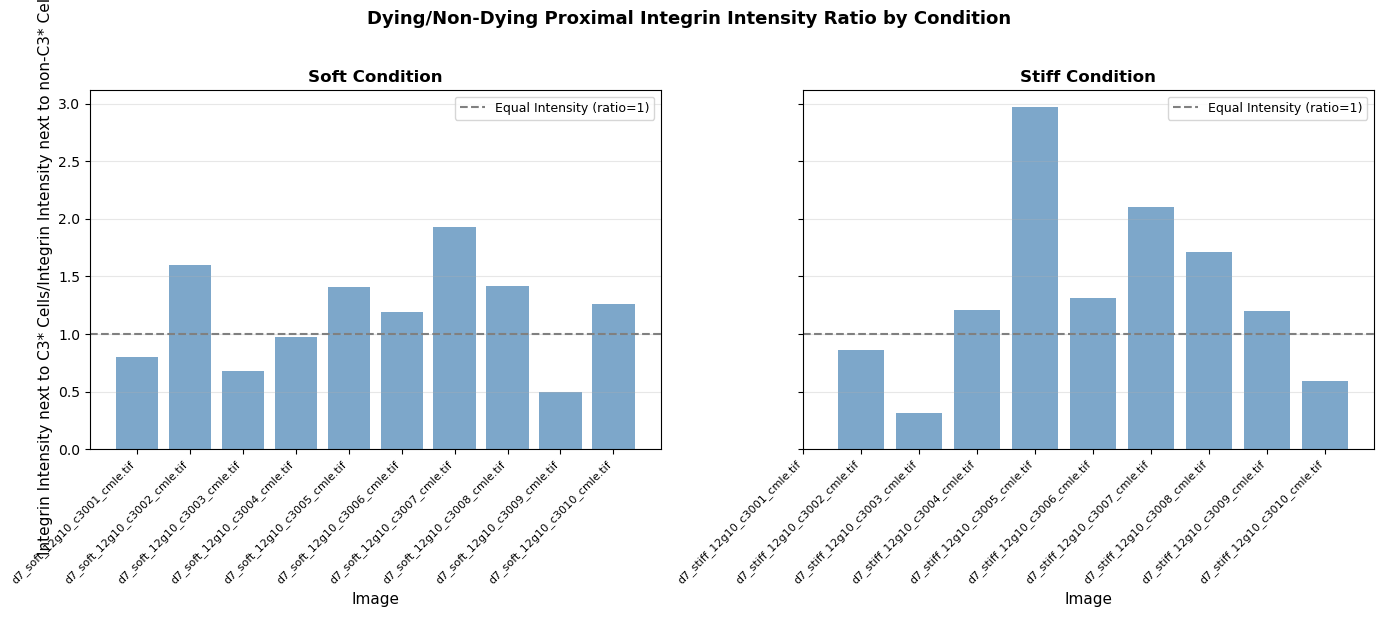


Ratio > 1: Dying cells have higher proximity intensity
Ratio < 1: Dying cells have lower proximity intensity
Ratio = 1: Equal proximity intensity


In [149]:
# Calculate ratio of dying to non-dying proximity intensity for each filename
# Add condition information if not already there
if 'condition' not in avg_pivot.columns:
    avg_pivot['condition'] = avg_pivot['filename'].apply(
        lambda x: 'soft' if 'soft' in x else ('stiff' if 'stiff' in x else 'other')
    )

# Calculate ratio (dying / non-dying)
avg_pivot['dying_to_nondying_ratio'] = avg_pivot['dying_avg'] / avg_pivot['non_dying_avg']

# Separate soft and stiff data
soft_data = avg_pivot[avg_pivot['condition'] == 'soft'].reset_index(drop=True)
stiff_data = avg_pivot[avg_pivot['condition'] == 'stiff'].reset_index(drop=True)

# Create side-by-side bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# SOFT condition ratio plot
if len(soft_data) > 0:
    x_soft = np.arange(len(soft_data))
    
    bars1 = ax1.bar(x_soft, soft_data['dying_to_nondying_ratio'], color='steelblue', alpha=0.7)
    
    # Add horizontal line at y=1 (equal intensity)
    ax1.axhline(y=1, color='gray', linestyle='--', linewidth=1.5, label='Equal Intensity (ratio=1)')
    
    ax1.set_xlabel('Image', fontsize=11)
    ax1.set_ylabel('Integrin Intensity next to C3* Cells/Integrin Intensity next to non-C3* Cells', fontsize=11)
    ax1.set_title('Soft Condition', fontsize=12, fontweight='bold')
    ax1.set_xticks(x_soft)
    ax1.set_xticklabels(soft_data['filename'], rotation=45, ha='right', fontsize=8)
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

# STIFF condition ratio plot
if len(stiff_data) > 0:
    x_stiff = np.arange(len(stiff_data))
    
    bars2 = ax2.bar(x_stiff, stiff_data['dying_to_nondying_ratio'], color='steelblue', alpha=0.7)
    
    # Add horizontal line at y=1 (equal intensity)
    ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1.5, label='Equal Intensity (ratio=1)')
    
    ax2.set_xlabel('Image', fontsize=11)
    ax2.set_title('Stiff Condition', fontsize=12, fontweight='bold')
    ax2.set_xticks(x_stiff)
    ax2.set_xticklabels(stiff_data['filename'], rotation=45, ha='right', fontsize=8)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Dying/Non-Dying Proximal Integrin Intensity Ratio by Condition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nRatio > 1: Dying cells have higher proximity intensity")
print(f"Ratio < 1: Dying cells have lower proximity intensity")
print(f"Ratio = 1: Equal proximity intensity")

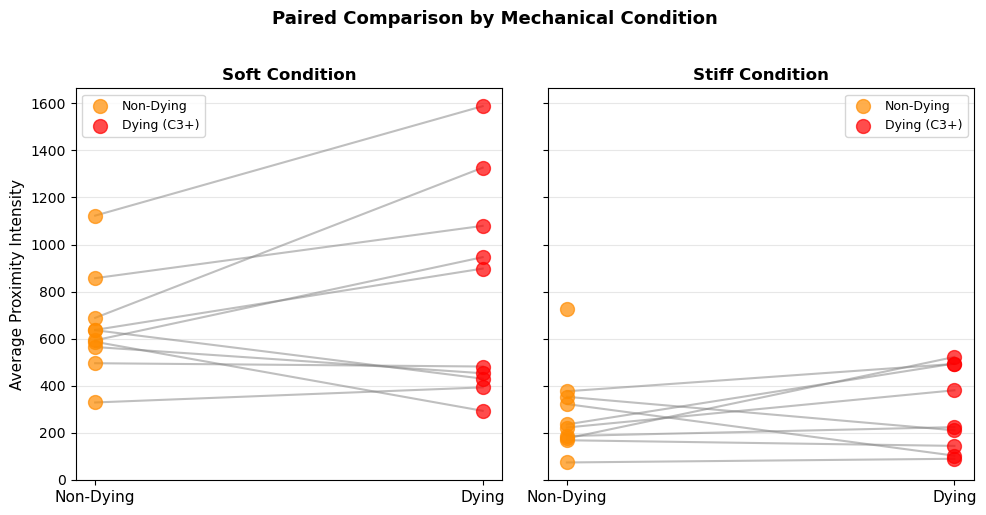

Soft condition: 10 images
Stiff condition: 10 images


In [ ]:
# Create paired plots separated by condition (soft vs stiff)
# First, add condition information to the avg_pivot dataframe
avg_pivot_with_condition = avg_pivot.copy()
avg_pivot_with_condition['condition'] = avg_pivot_with_condition['filename'].apply(
    lambda x: 'soft' if 'soft' in x else ('stiff' if 'stiff' in x else 'other')
)

# Filter for soft and stiff conditions
soft_data = avg_pivot_with_condition[avg_pivot_with_condition['condition'] == 'soft']
stiff_data = avg_pivot_with_condition[avg_pivot_with_condition['condition'] == 'stiff']

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# SOFT condition plot
soft_non_dying = soft_data['non_dying_avg'].values
soft_dying = soft_data['dying_avg'].values

ax1.scatter(np.zeros(len(soft_non_dying)), soft_non_dying, 
           s=100, color='darkorange', alpha=0.7, label='Non-Dying', zorder=3)
ax1.scatter(np.ones(len(soft_dying)), soft_dying, 
           s=100, color='red', alpha=0.7, label='Dying (C3+)', zorder=3)

for i in range(len(soft_non_dying)):
    ax1.plot([0, 1], [soft_non_dying[i], soft_dying[i]], 
            'gray', alpha=0.5, linewidth=1.5, zorder=2)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Non-Dying', 'Dying'], fontsize=11)
ax1.set_ylabel('Average Proximity Intensity', fontsize=11)
ax1.set_title('Soft Condition', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# STIFF condition plot
stiff_non_dying = stiff_data['non_dying_avg'].values
stiff_dying = stiff_data['dying_avg'].values

ax2.scatter(np.zeros(len(stiff_non_dying)), stiff_non_dying, 
           s=100, color='darkorange', alpha=0.7, label='Non-Dying', zorder=3)
ax2.scatter(np.ones(len(stiff_dying)), stiff_dying, 
           s=100, color='red', alpha=0.7, label='Dying (C3+)', zorder=3)

for i in range(len(stiff_non_dying)):
    ax2.plot([0, 1], [stiff_non_dying[i], stiff_dying[i]], 
            'gray', alpha=0.5, linewidth=1.5, zorder=2)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Non-Dying', 'Dying'], fontsize=11)
ax2.set_title('Stiff Condition', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Paired Comparison by Mechanical Condition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Soft condition: {len(soft_data)} images")
print(f"Stiff condition: {len(stiff_data)} images")

In [146]:
# Calculate correlation coefficients between non-dying and dying proximity intensities
from scipy.stats import pearsonr

# Add condition to avg_pivot if not already there
if 'condition' not in avg_pivot.columns:
    avg_pivot['condition'] = avg_pivot['filename'].apply(
        lambda x: 'soft' if 'soft' in x else ('stiff' if 'stiff' in x else 'other')
    )

# Drop rows with NaN values in either column
avg_pivot_clean = avg_pivot.dropna(subset=['non_dying_avg', 'dying_avg'])

# Separate by condition
soft_data = avg_pivot_clean[avg_pivot_clean['condition'] == 'soft']
stiff_data = avg_pivot_clean[avg_pivot_clean['condition'] == 'stiff']

print("="*60)
print("CORRELATION ANALYSIS: Non-Dying vs Dying Proximity Intensity")
print("="*60)

# Soft condition correlation
if len(soft_data) > 1:
    soft_corr, soft_p = pearsonr(soft_data['non_dying_avg'], soft_data['dying_avg'])
    print(f"\nSOFT CONDITION (n={len(soft_data)} images):")
    print(f"  Pearson correlation coefficient: {soft_corr:.4f}")
    print(f"  P-value: {soft_p:.4e}")
    if soft_p < 0.05:
        print(f"  → Statistically significant correlation (p < 0.05)")
    else:
        print(f"  → Not statistically significant (p ≥ 0.05)")
    
    if soft_corr > 0:
        print(f"  → Positive correlation: Higher non-dying intensity → Higher dying intensity")
    else:
        print(f"  → Negative correlation: Higher non-dying intensity → Lower dying intensity")
else:
    print(f"\nSOFT CONDITION: Insufficient data (n={len(soft_data)})")

# Stiff condition correlation
if len(stiff_data) > 1:
    stiff_corr, stiff_p = pearsonr(stiff_data['non_dying_avg'], stiff_data['dying_avg'])
    print(f"\nSTIFF CONDITION (n={len(stiff_data)} images):")
    print(f"  Pearson correlation coefficient: {stiff_corr:.4f}")
    print(f"  P-value: {stiff_p:.4e}")
    if stiff_p < 0.05:
        print(f"  → Statistically significant correlation (p < 0.05)")
    else:
        print(f"  → Not statistically significant (p ≥ 0.05)")
    
    if stiff_corr > 0:
        print(f"  → Positive correlation: Higher non-dying intensity → Higher dying intensity")
    else:
        print(f"  → Negative correlation: Higher non-dying intensity → Lower dying intensity")
else:
    print(f"\nSTIFF CONDITION: Insufficient data (n={len(stiff_data)})")

# Overall correlation (all conditions combined)
if len(avg_pivot_clean) > 1:
    overall_corr, overall_p = pearsonr(avg_pivot_clean['non_dying_avg'], avg_pivot_clean['dying_avg'])
    print(f"\nOVERALL (all conditions, n={len(avg_pivot_clean)} images):")
    print(f"  Pearson correlation coefficient: {overall_corr:.4f}")
    print(f"  P-value: {overall_p:.4e}")
    if overall_p < 0.05:
        print(f"  → Statistically significant correlation (p < 0.05)")
    else:
        print(f"  → Not statistically significant (p ≥ 0.05)")

print("="*60)

CORRELATION ANALYSIS: Non-Dying vs Dying Proximity Intensity

SOFT CONDITION (n=10 images):
  Pearson correlation coefficient: 0.8040
  P-value: 5.0580e-03
  → Statistically significant correlation (p < 0.05)
  → Positive correlation: Higher non-dying intensity → Higher dying intensity

STIFF CONDITION (n=9 images):
  Pearson correlation coefficient: 0.2395
  P-value: 5.3478e-01
  → Not statistically significant (p ≥ 0.05)
  → Positive correlation: Higher non-dying intensity → Higher dying intensity

OVERALL (all conditions, n=19 images):
  Pearson correlation coefficient: 0.8291
  P-value: 1.1470e-05
  → Statistically significant correlation (p < 0.05)
